<a href="https://colab.research.google.com/github/telmacarvalho/cases/blob/main/case_stockout_turnover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#__Case Tecnico__

##__Problema 1: Problema do stockout__

Uma rede de supermercados sofre com a constante falta de alguns produtos, mais especificamente cerveja. Quando os funcionários notam a falta dos produtos em estoque, eles fazem um pedido à matriz para que enviem mais unidades do centro de distribuição para a loja, mas os caminhões podem demorar até 3 dias para chegar a seu destino, fazendo com que a loja perca várias vendas. O cliente pede que um modelo preditivo seja construído, a fim de que cada loja possa saber, com antecedência, quando haverá uma falta de estoque. Eles mencionam ter uma tabela de histórico de ocorrência de stockout por loja, produto e dia, além de algumas outras informações que podem ser úteis (mas não especificam quais).

### A.  Que tipos de dados você perguntaria se eles têm e qual granularidade você pediria? Ou que tipo de informações externas você buscaria? Explique o racional por trás de suas escolhas.

Para construir um modelo preditivo eficaz, preciso entender a demanda e a dinâmica de suprimentos como estoque e tempo de entrega.

Os tipos de dados internos que solicitaria seriam:

* Histórico de vendas para compreender padrões de consumo, tendências e sazonalidade;
* Histórico de estoque para entender a taxa de consumo e identificar níveis de estoque que podem anteceder a falta do produto;
* Histórico de ocorrência de stockout (tabela que a empresa já dispõe) para treinar o modelo com o histórico das ocorrências da ausência de estoque;
* Histórico de pedidos de reposição para confirmar o tempo de entrega;
* Historíco de promoções pois podem impactar nas vendas.

A granularidade dos dados que pediria, seria diária, por produto e loja, com intuito de captar as flutuações de venda e estoque de maneira a permitir uma previsão dentro do range de 3 dias indicados.

Os tipos de informações externas que iria captar seria:

* Calendário para ter visibilidade dos feriados pois o consumo de cerveja tende a aumentar nesses dias;
* Eventos locais que podem aumentar as vendas;
* Dados meterológicos também, pois dias quentes podem aumentar o consumo de cerveja.

### B. Escolha um dos problemas abaixo, relacionados a dados de séries temporais, e sugira uma implementação para resolver ou mitigar o problema:

    *   Algumas das features (por exemplo, vendas_diarias) tem muitos outliers
    *   Algumas lojas e produtos têm pouca quantidade de dados
    *   Série temporal de informação de stockout são muito esparsas (as séries  são compostas majoritariamente por valores nulos, com alguns valores não-nulos espalhados de maneira irregular)





Escolho o problema: Série temporal de informação de stockout são muito esparsas (as séries  são compostas majoritariamente por valores nulos, com alguns valores não-nulos espalhados de maneira irregular).

Devido ao grande volume de nulos que indicam falta de estoque, temos um conjunto de dados desbalanceado. Isso ocasiona uma baixa capacidade de aprendizagem para modelos de séries temporais.

Diante disso, sugiro transformar o problema para uma classificação supervisionada, onde podemos prever se haverá stockout ou não dentro de 3 dias.

Essa mudança nos permite usar modelos de árvores de decisão como XGBoost e LightGBM, que lindam bem com classes desbalanceadas devido ao hiperparâmetro scale_pos_weight que dá um peso maior a classe minoritária.

A implementação de solução que sugiro seria:

**1. Feature Engineering**

O primeiro passo seria criar novos atributos a partir dos tipos de dados que indiquei na resposta anterior como histórico de vendas, estoque, calendário, feriados, dias quentes, etc.

**2. Tratamento do Desbalanceamento**

Faria a computação do hipeparâmetro scale_pos_weight, divindo a quantidade de classes negativas pela positiva.

Também poderia adotar o oversampling, criando dados sintéticos da classe minoritária, e/ou undesampling, diminuindo dados da classe marojitária afim de melhorar as métricas do modelo.

**3. Modelagem e Treinamento**

Com divisão de dados para treinamento e teste do algoritmo.

**4. Avaliação das Métricas**

Daria foco na métrica AUC e F1 Score, que apresenta o equilibrio entre Recall e Precision, que são o mais indicado para conjunto de dados desbalanceados. Tendo em vista que, ainda que Accuracy seja alta, não indica que o modelo está prevendo por conta do desbalanceamento.

Também iria analisar a matriz de confusão para entender a proporção quantitativa de falsos positivos e falsos negativos.

##__Problema 2: Problema de turnover__

Você trabalha em uma empresa de produtos alimentícios que sofre com grande taxa de turnover (ou seja, funcionários que deixam a empresa). O departamento de RH está buscando entender o que leva seus funcionários a deixarem a empresa ou não.

Assuma que a empresa possui um dataset com as seguintes colunas e aproximadamente 5 anos de dados:

    *  employee_id: Identificação única do funcionário.

    *  manager_id: ID do gerente do funcionário

    *  employee_name: Nome do funcionário

    *  age: Idade do funcionário

    *  gender: Gênero do funcionário

    *  food_preferences: Preferências alimentares registradas para eventos corporativos

    *  social_media_handle: Identificadores de redes sociais utilizadas pelo funcionário

    *  job_level: Nível do cargo ocupado (de 1 a 5)

    *  monthly_income: Salário mensal.

    *  years_at_company: Anos trabalhados na empresa.

    *  distance_from_home: Distância da casa até o trabalho (em km)

    *  over_time: Se o funcionário faz horas extras (Sim ou Não).

    *  company_car_assigned: Informação sobre se o funcionário tem um carro da empresa

    *  turnover: 1 se o funcionário deixou a empresa, 0 se não deixou

### A. Desenvolva uma estratégia para prever a variável turnover. Quais etapas esse projeto deveria ter, desde a coleta de dados até a disponibilização dos resultados? (Descreva bem as etapas e as atividades em cada uma delas)

Para prever o turnover, eu seguiria as seguintes etapas:

**1. Entendimento do Negócio**

* Reunião com Stakeholders (RH): Entender a fundo a dor do negócio. Qual é o custo do turnover? Se existem áreas ou cargos mais afetados.
* Definição do Objetivo: O objetivo principal seria criar um modelo que identifique funcionários com maior probabilidade de deixar a empresa nos próximos 3 a 6 meses, para que o RH possa tomar ações para evitar a evasão.
* Definição de Resultados Esperados:
  * Métricas de Modelo: se a maioria dos funcionários não sai da empresa, teremos um desbalanceamento de dados, então não usaremos Acuracy. Daremos enfoque em Recall para garantir que estamos identificando a maior parte dos funcionários que realmente vão deixar a empresa - e AUC-PR.
  * Métricas de Negócio: Redução da taxa de turnover em quantos % após um prazo estabaelcido depois de implementar ações preventivas com indicação do modelo.

**2. Análise Exploratória de Dados (EDA )**

* Entender a distribuição de cada variável. Qual a distribuição de idade (age), salário (monthly_income), anos de empresa (years_at_company)? Qual a proporção de funcionários que fazem hora extra (over_time)?
* Verificar o balanceamento da variável turnover. A proporção da classe 1 provavelmente será baixa, confirmando a necessidade de técnicas específicas para mitigar esse problema.
* Cruzar cada atributo com o turnover para entender a correlação: se funcionários com maior salários saem mais, se o nível do cargo influencia na saída e se a distância apresenta algum fato relevante.
* Identificar de dados sauentes e outliers.

**3. Pré-processamento e Feature Engineering**

* Limpeza de Dados: Tratar valores ausentes, se houver com imputação pela média/mediana, por exemplo.

* Remoção de Features Irrelevantes: Colunas como employee_id, employee_name, social_media_handle e food_preferences, porque são identificadores únicos ou dados sensíveis que não agregam valor para previsão e a última pode adicionar ruído para o modelo.

* Codificação de Variáveis Categóricas: Transformar variáveis como gender e over_time em formato numérico.

* Criação de Novas Features:

  * income_per_year_at_company: monthly_income / years_at_company que pode indicar estagnação salarial.
  * manager_turnover_rate: Agrupar por manager_id para calcular a taxa histórica de turnover da equipe de cada gerente, porque um gerente com alta taxa de turnover na sua equipe pode ser um forte preditor.
  * age_group: Criar faixas etárias.

**4. Modelagem e Treinamento**

* Divisão dos Dados: Separar os dados em conjuntos de treino, validação e teste. Uma abordagem temporal, treinando com os 4 primeiros anos e testar com o último ano, por exempĺo, seria ideal para simular um cenário real.
* Estabelecer um Baseline: Criar um modelo simples como Regressão Logística para ter uma base de comparação de performance.
* Treinamento de Modelos: Treinar outros algoritmos no conjunto de treino.
* Tratamento de Desbalanceamento: Aplicar técnicas como class_weight para ponderar a classe minoritária durante o treinamento.
* Otimização de Hiperparâmetros: Usar técnicas como Grid Search com validação cruzada no conjunto de treino/validação para encontrar os melhores parâmetros para o modelo.

**5. Avaliação e Interpretação**

* Avaliação no Conjunto de Teste: Usar o conjunto de teste para avaliar a performance final usando as métricas definidas (Recall, AUC-PR).
* Interpretação do Modelo: Utilizar ferramentas como SHAP OU ou Feature Importance para entender quais fatores mais contribuem para a previsão de turnover. Isso irá auxiliar muito o RH.
* Geração de Insights: Transformar os resultados do modelo em recomendações acionáveis para o negócio.

**6. Disponibilização dos Resultados e Implantação**

* Criação de Relatório e/ou Dashboard: Apresentar os resultados de forma clara para o RH, destacando os principais indicadores de turnover e a lista de funcionários com alto risco.
* Implantação (Deploy): O modelo pode ser implantado como um processo em batch que roda mensalmente nos dados atuais dos funcionários para gerar uma pontuação de risco de turnover.
* Monitoramento: Acompanhar a performance do modelo ao longo do tempo para detectar quando o modelo perde performance devido a mudança de comportamento dos dados e planejar o retreino periódico.

### B. Que tipo de algoritmo você aplicaria/testaria e por quê?

Eu testaria alguns algoritmos, começando do mais simples e interpretável para o mais complexo e robusto.

**Regressão Logística:**
Porque é um excelente modelo de baseline. É rápido, computacionalmente leve e bem interpretável.

**Random Forest:**
Porque é um algoritmo robusto e que geralmente apresenta ótima performance. É menos sensível a outliers e não exige o escalonamento das features. Além disso, O modelo também calcula de forma nativa a feature_importance, que aponta os principais fatores que levam ao turnover.

**LightGBM ou XGBoost:**
Porque são frequentemente os modelos com a melhor performance para dados tabulares como este. Eles são capazes de capturar relações complexas e não-lineares nos dados.

### C. Agora considere que, por questões burocráticas, o projeto teve que ser reduzido e você terá apenas metade do tempo para executá-lo. Que atividades você cortaria ou reduziria e por quê?

Meu foco iria mudar para entregar um MVP que forneça o maior valor no menor tempo.

Atividades que eu cortaria ou reduziria:
* Engenharia de Atributos Complexa (reduziria) porque focaria em features mais diretas e fáceis de calcular, pois pode se gastar um tempo consideravelmente longo com engenharia de atributos.
* Otimização de Hiperparâmetros (cortaria) porque é um processo de ajuste fino que consome muito tempo computacional e iria usar os parâmetros padrão do LightGBM, que costumam ser muito bons.
* Testes com Múltiplos Algoritmos (CORcortaria), eu escolheria apenas um algoritmo para focar e iria direto para o LightGBM devido sua ótima combinação de velocidade de treinamento e alta performance.
* Implantação e Monitoramento Formal (cortaria), a entrega não seria um sistema em produção, mas sim um relatório de análise com notebook ou uma apresentação contendo os principais fatores que levam ao turnover e uma lista dos funcionários atualmente com maior risco.

##__Problema 3: Análise de regressão__

Uma empresa da indústria farmacêutica tem uma nova política interna para não discriminar significativamente os salários de acordo com a localização de seus funcionários. Eles coletaram os dados de todos os funcionários e querem que você verifique se eles já estão seguindo a nova política. Antes de responder às perguntas abaixo, dê uma olhada no conjunto de dados em anexo: (1stPhase-SelectiveProcess-Data Science-Data Base.csv)

### A.  Descreva como você pode usar os dados do supermercado para verificar se os funcionários de diferentes locais têm salários significativamente diferentes. (Inclua aqui como você tratará as variáveis antes de inseri-las no modelo e todas as etapas que pretende seguir aprofundando o máximo possível em sua explicação)

Para verificar se os funcionários de diferentes locais possuem salários significativamente diferentes, podemos seguir um fluxo analítico baseado em regressão linear múltipla. A seguir, detalho as etapas que seguiria:

**1. Definição do Modelo e Hipóteses:**

* Variável Dependente (Y): SALARIO_MENSAL.

* Variáveis Independentes (X): EDUCAÇÃO, CARGO, LOCAL, IDADE, TEMPOCASA. A variável de interesse principal é LOCAL.

* Hipótese Nula (H₀): A localização (LOCAL) não tem um efeito estatisticamente significativo sobre o salário mensal, quando controlamos os efeitos de educação, cargo, idade e tempo de casa. Em termos do modelo de regressão, isso significa que o coeficiente associado à variável LOCAL é igual a zero.

* Hipótese Alternativa (H₁): A localização (LOCAL) tem um efeito estatisticamente significativo sobre o salário mensal, mesmo após controlar as outras variáveis. O coeficiente associado à variável LOCAL é diferente de zero.

**2. Tratamento e Preparação dos Dados:**

* Variáveis Categóricas: As variáveis EDUCAÇÃO, CARGO e LOCAL são categóricas e precisam ser convertidas em um formato numérico que o modelo de regressão possa entender. A técnica mais comum é a criação de variáveis dummy (ou one-hot encoding). Para cada variável categórica, novas colunas binárias (0 ou 1) seriam criadas para cada categoria. Por exemplo, para a variável LOCAL, que tem as categorias 'CAPITAL' e 'INTERIOR', criaríamos uma coluna chamada LOCAL_CAPITAL. Se um funcionário for da capital, o valor nesta coluna seria 1; caso contrário, seria 0. A outra categoria ('INTERIOR') serviria como a categoria de referência (baseline).

* Variáveis Numéricas: As variáveis IDADE e TEMPOCASA já são numéricas e podem ser incluídas diretamente no modelo. Não é estritamente necessário escalonar para a regressão linear (não obrigatório em OLS).

**3. Construção e Análise do Modelo de Regressão:**

Depois da preparação dos dados, um modelo de Regressão Linear Múltipla OLS (Mínimos Quadrados Ordinários) seria ajustado aos dados. A equação do modelo teria a seguinte forma:

$SALARIO\_MENSAL =  \beta_0 + \beta_1 . EDUCACAO + \beta_2 . CARGO + \beta_3 . LOCAL + \beta_4 . IDADE + \beta_5 . TEMPOCASA + \epsilon $  

Onde os $\beta $ são so coeficientes que o modelo vai estimar.

Assim isolamos o efeito de LOCAL sobre o salário, controlando outras variáveis que também afetam a remuneração.

**4. Avaliação e Interpretação:**

* Se o p-valor associado à variável LOCAL for menor que um nível de significância pré-definido (p-valor < 0.05), rejeitaría a hipótese nula. O que nos leva a concluir que existe uma diferença salarial significativa entre funcionários da capital e do interior, mesmo após controlar por nível de educação, cargo, idade e tempo de casa.
* Se o p-valor for maior que 0.05, não tería evidências estatísticas suficientes para rejeitar a hipótese nula, sugerindo que a empresa está alinhada com sua política de não discriminação salarial baseada na localização.

### B. Imagine que, depois de olhar os dados, você tenha uma reunião com o cliente em que poderá mostrar alguns gráficos e fazer comentários e/ou perguntas para ele sobre os dados. Quais visuais você levaria e quais comentários/perguntas você faria?

Para uma reunião com o cliente, eu iria preparar os seguintes gráficos:

* Box Plot de Salários por Localização: Um box plot comparando a distribuição dos salários mensais entre 'CAPITAL' e 'INTERIOR'.

  Esse gráfico nos dá uma visão geral da distribuição dos salários em cada local. Podemos observar a mediana, os quartis e a presença de possíveis outliers. À primeira vista, parece que a mediana salarial na capital é ligeiramente superior à do interior.

* Box Plot de Salários por Cargo: Um box plot comparando a distribuição dos salários mensais para cada CARGO ('AUXILIAR', 'GERENTE', 'DIRETOR').

  Com esse gráfico vemos como os salários se distribuem entre os diferentes cargos. Como esperado, diretores têm uma faixa salarial superior à de gerentes e auxiliares.

* Gráfico de Barras da Contagem de Funcionários por Local e Cargo: Um gráfico de barras mostrando a quantidade de funcionários em cada cargo, segmentado por localização.

  Podemos observar que a proporção de cargos de liderança (Gerente, Diretor) parece ser diferente entre a Capital e o Interior. Isso reflete a estrutura organizacional da empresa? Essa diferença na composição dos cargos por local pode ser um fator que explica as diferenças salariais que observamos.

Também faria as seguintes perguntas:

* Além das variáveis que temos (educação, cargo, idade, tempo de casa, local), existem outros fatores que influenciam a remuneração, como avaliações de desempenho, bônus, área de atuação ou certificações específicas?

* Há políticas de bônus regionais que podem justificar pequenas diferenças salariais?

Obs: A ausência desses dados pode limitar nossa análise.

* A política de não discriminação salarial é recente? Se sim, os dados que temos refletem a estrutura salarial antes ou depois da implementação dessa política?

* Qual nível de diferença salarial a empresa consideraria 'significativamente diferente' do ponto de vista prático e de negócio? A análise estatística pode indicar uma diferença, mas a empresa precisa definir o que é uma diferença material.

### C.  Implemente a sua abordagem da melhor forma possível em um código  Python, comentando as etapas do seu código. Não esqueça de trazer uma conclusão final.

In [ ]:
# Importação das bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
# 1. Extração e inspeção dos dados
file_path = "/content/1st_Phase_-_Selective_Process_-_Data_Science_-_DataBase.xlsx"
df = pd.read_excel(file_path)
print("\n Informações gerais:")
print(df.info())
print("\n Visualização inicial:")
df.head()


 Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              80 non-null     int64  
 1   EDUCAÇÃO        80 non-null     object 
 2   CARGO           80 non-null     object 
 3   LOCAL           80 non-null     object 
 4   IDADE           80 non-null     int64  
 5   TEMPOCASA       80 non-null     int64  
 6   SALARIO_MENSAL  80 non-null     float64
dtypes: float64(1), int64(3), object(3)
memory usage: 4.5+ KB
None

 Visualização inicial:


,ID,EDUCAÇÃO,CARGO,LOCAL,IDADE,TEMPOCASA,SALARIO_MENSAL
0,1,SECUNDÁRIO,GERENTE,INTERIOR,30,1,4279.5
1,2,SUPERIOR,AUXILIAR,INTERIOR,32,4,4575.4
2,3,SECUNDÁRIO,AUXILIAR,CAPITAL,33,2,4735.6
3,4,SUPERIOR,GERENTE,INTERIOR,34,3,4863.1
4,5,SECUNDÁRIO,GERENTE,INTERIOR,36,1,5355.8


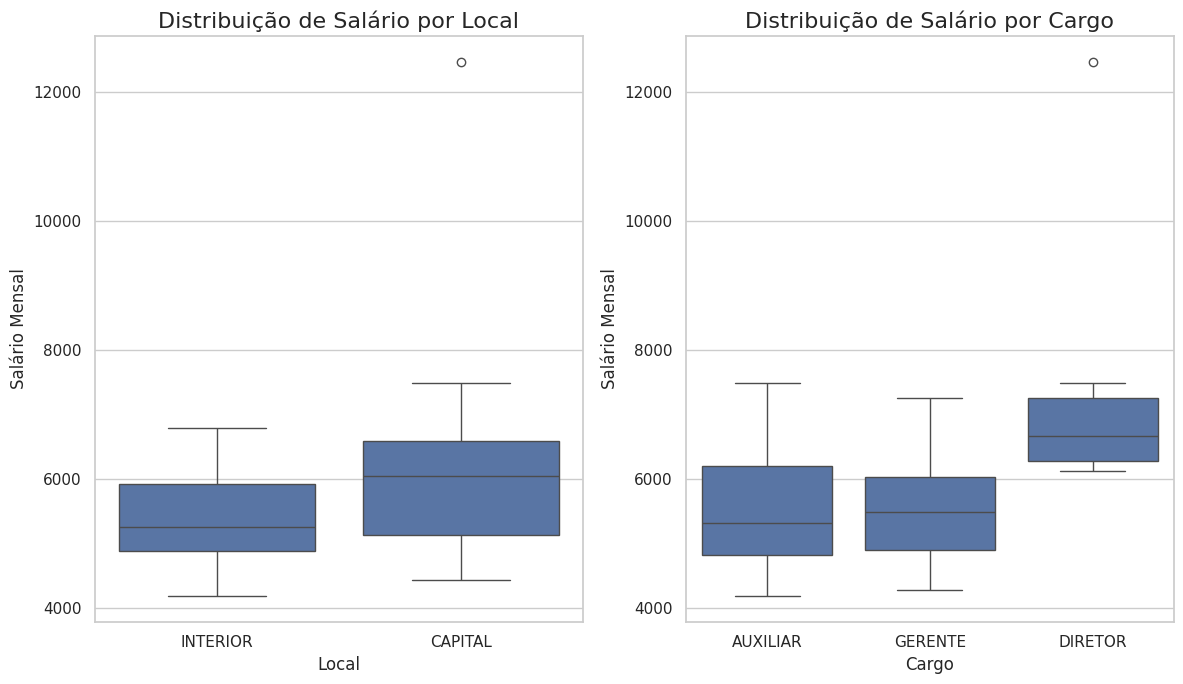

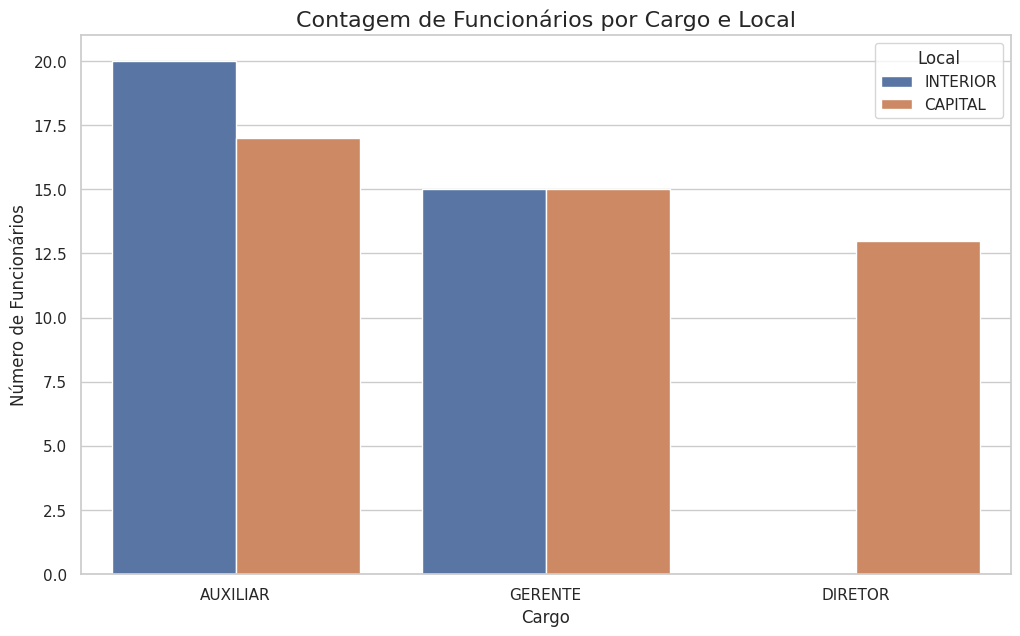

In [ ]:
# 2. Análise Visual Exploratória

# Definie o estilo dos gráficos
sns.set(style="whitegrid")

# Cria os box plots para visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# Box plot de Salário por Local
sns.boxplot(x='LOCAL', y='SALARIO_MENSAL', data=df, ax=axes[0])
axes[0].set_title('Distribuição de Salário por Local', fontsize=16)
axes[0].set_xlabel('Local', fontsize=12)
axes[0].set_ylabel('Salário Mensal', fontsize=12)

# Box plot de Salário por Cargo
sns.boxplot(x='CARGO', y='SALARIO_MENSAL', data=df, order=['AUXILIAR', 'GERENTE', 'DIRETOR'], ax=axes[1])
axes[1].set_title('Distribuição de Salário por Cargo', fontsize=16)
axes[1].set_xlabel('Cargo', fontsize=12)
axes[1].set_ylabel('Salário Mensal', fontsize=12)

plt.tight_layout()

# Criar uma figura para o novo gráfico
plt.figure(figsize=(12, 7))

# Criar o gráfico de contagem (countplot)
sns.countplot(x='CARGO', hue='LOCAL', data=df, order=['AUXILIAR', 'GERENTE', 'DIRETOR'])

# Adicionar título e legendas
plt.title('Contagem de Funcionários por Cargo e Local', fontsize=16)
plt.xlabel('Cargo', fontsize=12)
plt.ylabel('Número de Funcionários', fontsize=12)
plt.legend(title='Local')

# Exibir o gráfico
plt.show()


In [ ]:
# 3. Preparação dos Dados para Regressão

# Cria variáveis dummy para as variáveis categóricas
df_dummies = pd.get_dummies(
    df, columns=['EDUCAÇÃO', 'CARGO', 'LOCAL'], drop_first=True)
print("Tipos de dados antes da conversão:")
print(df_dummies.info())

# Convert as variáveis tipo boleano para inteiro
for col in df_dummies.columns:
    if df_dummies[col].dtype == 'bool':
        df_dummies[col] = df_dummies[col].astype(int)
print("\n Tipos de dados após a conversão de bool para int:")
print(df_dummies.info())


Tipos de dados antes da conversão:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 80 non-null     int64  
 1   IDADE              80 non-null     int64  
 2   TEMPOCASA          80 non-null     int64  
 3   SALARIO_MENSAL     80 non-null     float64
 4   EDUCAÇÃO_SUPERIOR  80 non-null     bool   
 5   CARGO_DIRETOR      80 non-null     bool   
 6   CARGO_GERENTE      80 non-null     bool   
 7   LOCAL_INTERIOR     80 non-null     bool   
dtypes: bool(4), float64(1), int64(3)
memory usage: 2.9 KB
None

 Tipos de dados após a conversão de bool para int:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 80 non-null     int64  
 1   IDADE           

In [ ]:
# Define as variáveis independentes (X) e a variável dependente (y)
X = df_dummies.drop(['ID', 'SALARIO_MENSAL'], axis=1)
y = df_dummies['SALARIO_MENSAL']

# Adiciona uma constante (necessário para o statsmodels)
X = sm.add_constant(X)
print('\n Tipo da variável alvo (y):',y.dtype)
print('\n Variáveis preditoras (X) processadas:')
X.head()



 Tipo da variável alvo (y): float64

 Variáveis preditoras (X) processadas:


,const,IDADE,TEMPOCASA,EDUCAÇÃO_SUPERIOR,CARGO_DIRETOR,CARGO_GERENTE,LOCAL_INTERIOR
0,1.0,30,1,0,0,1,1
1,1.0,32,4,1,0,0,1
2,1.0,33,2,0,0,0,0
3,1.0,34,3,1,0,1,1
4,1.0,36,1,0,0,1,1


In [ ]:
# 4. Construção e Análise do Modelo de Regressão ---

# Criando e ajustando o modelo de regressão linear (OLS - Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Exibindo o sumário completo dos resultados da regressão
print("\n Resultados da Análise de Regressão:")
print(model.summary())


 Resultados da Análise de Regressão:
                            OLS Regression Results                            
Dep. Variable:         SALARIO_MENSAL   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     20.33
Date:                Fri, 10 Oct 2025   Prob (F-statistic):           7.77e-14
Time:                        05:51:36   Log-Likelihood:                -636.69
No. Observations:                  80   AIC:                             1287.
Df Residuals:                      73   BIC:                             1304.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------


**Conclusão Final:**

Não há evidências estatísticas de discriminação salarial por localização.

O p-valor de 0.408 para a variável LOCAL_INTERIOR indica que, após controlar por fatores como tempo de casa e cargo, a diferença salarial entre um funcionário da capital e um do interior não é estatisticamente significativa.

Portanto, com base neste modelo, a empresa já está seguindo sua nova política interna de não discriminar salários de acordo com a localização de seus funcionários. As principais variáveis que de fato impactam o salário são o tempo de casa e ter um cargo de diretoria.